In [25]:
# Import library yang diperlukan
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [26]:
# Baca citra dari file
image_path = "objek-benda.jpg"

img_rgb = cv2.imread(image_path)
if img_rgb is None:
    raise ValueError(f"Gagal membaca citra dari {image_path}")

print(f"\nInformasi Citra RGB:")
print(f"  - Dimensi: {img_rgb.shape}")
print(f"  - Tipe data: {img_rgb.dtype}")
print(f"  - Min pixel value: {img_rgb.min()}")
print(f"  - Max pixel value: {img_rgb.max()}")


Informasi Citra RGB:
  - Dimensi: (736, 736, 3)
  - Tipe data: uint8
  - Min pixel value: 0
  - Max pixel value: 255


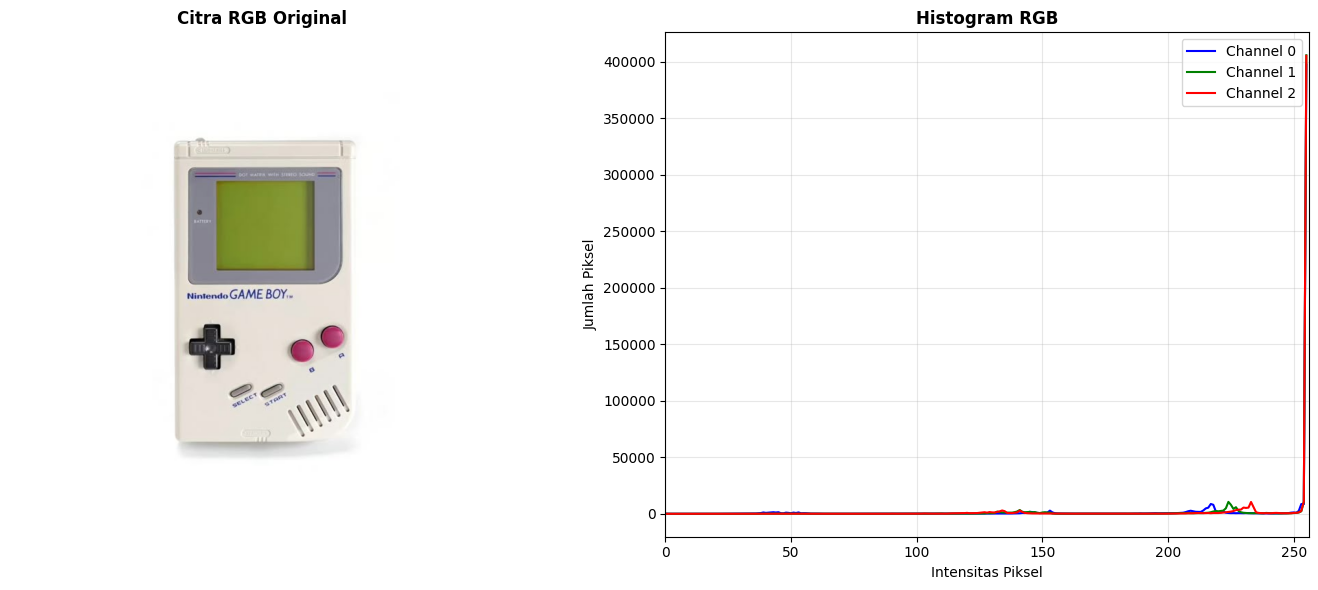

✓ Citra RGB original dan histogramnya telah ditampilkan
  Histogram menunjukkan distribusi intensitas untuk setiap channel (B, G, R)


In [27]:
# Tampilkan Citra RGB dan Histogram
fig1 = plt.figure(figsize=(14, 6))

# Tampilkan citra RGB
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB))
plt.title("Citra RGB Original", fontsize=12, fontweight='bold')
plt.axis('off')

# Tampilkan histogram RGB
plt.subplot(1, 2, 2)
colors = ('b', 'g', 'r')
for i, color in enumerate(colors):
    hist = cv2.calcHist([img_rgb], [i], None, [256], [0, 256])
    plt.plot(hist, color=color, linewidth=1.5, label=f'Channel {i}')
plt.title("Histogram RGB", fontsize=12, fontweight='bold')
plt.xlabel("Intensitas Piksel")
plt.ylabel("Jumlah Piksel")
plt.xlim([0, 256])
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Citra RGB original dan histogramnya telah ditampilkan")
print("  Histogram menunjukkan distribusi intensitas untuk setiap channel (B, G, R)")


Dimensi: (400, 400)
Tipe data: uint8
Min pixel value: 24
Max pixel value: 156


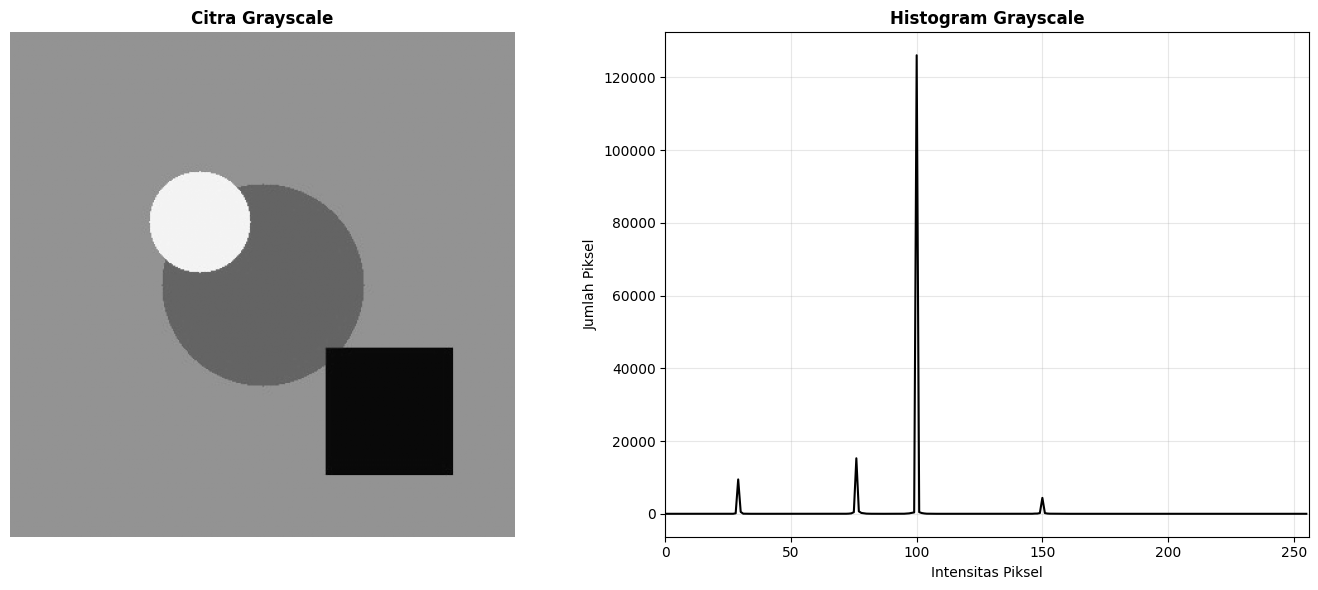


✓ Citra telah dikonversi ke grayscale
  Rumus: Grayscale = 0.299×R + 0.587×G + 0.114×B


In [28]:
# Konversi ke Grayscale
print(f"\nDimensi: {img_grayscale.shape}")
print(f"Tipe data: {img_grayscale.dtype}")
print(f"Min pixel value: {img_grayscale.min()}")
print(f"Max pixel value: {img_grayscale.max()}")

# Tampilkan Citra Grayscale dan Histogram
fig2 = plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_grayscale, cmap='gray')
plt.title("Citra Grayscale", fontsize=12, fontweight='bold')
plt.axis('off')

plt.subplot(1, 2, 2)
hist = cv2.calcHist([img_grayscale], [0], None, [256], [0, 256])
plt.plot(hist, color='black', linewidth=1.5)
plt.title("Histogram Grayscale", fontsize=12, fontweight='bold')
plt.xlabel("Intensitas Piksel")
plt.ylabel("Jumlah Piksel")
plt.xlim([0, 256])
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Citra telah dikonversi ke grayscale")
print("  Rumus: Grayscale = 0.299×R + 0.587×G + 0.114×B")


Dimensi: (400, 400)
Tipe data: uint8
Min pixel value: 99
Max pixel value: 231


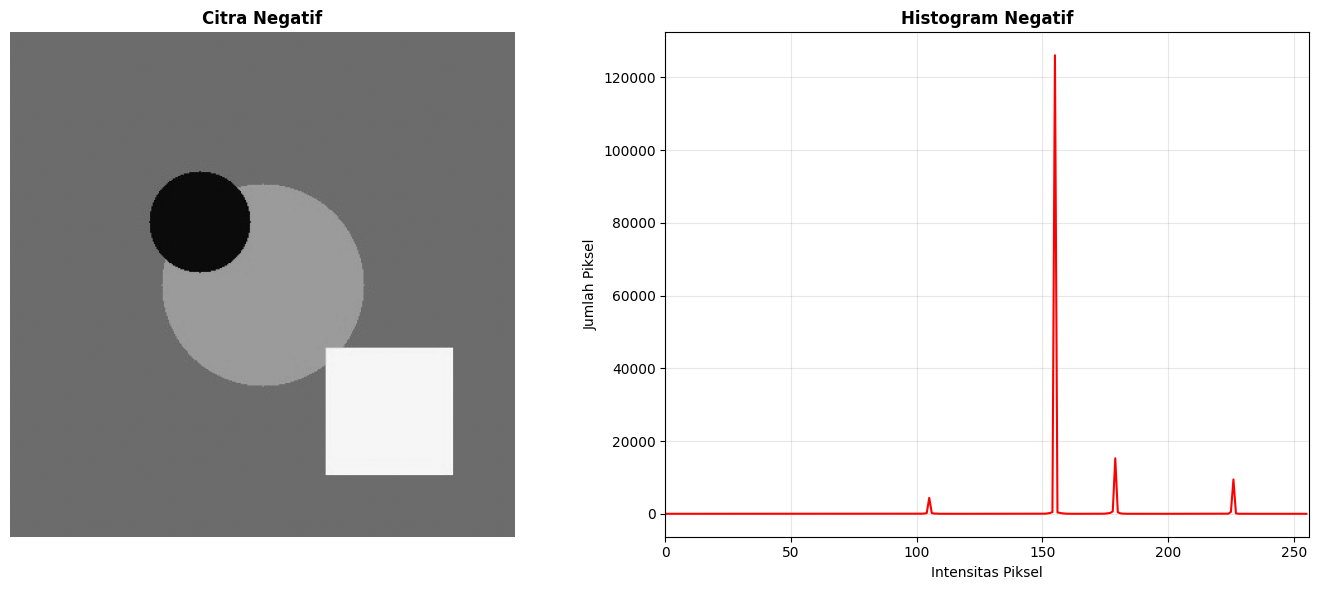


✓ Citra grayscale telah dikonversi ke negatif
  Rumus: Negatif = 255 - Grayscale


In [29]:
# Konversi ke Negatif
img_negative = 255 - img_grayscale
print(f"\nDimensi: {img_negative.shape}")
print(f"Tipe data: {img_negative.dtype}")
print(f"Min pixel value: {img_negative.min()}")
print(f"Max pixel value: {img_negative.max()}")

# Tampilkan Citra Negatif dan Histogram
fig3 = plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_negative, cmap='gray')
plt.title("Citra Negatif", fontsize=12, fontweight='bold')
plt.axis('off')

plt.subplot(1, 2, 2)
hist = cv2.calcHist([img_negative], [0], None, [256], [0, 256])
plt.plot(hist, color='red', linewidth=1.5)
plt.title("Histogram Negatif", fontsize=12, fontweight='bold')
plt.xlabel("Intensitas Piksel")
plt.ylabel("Jumlah Piksel")
plt.xlim([0, 256])
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Citra grayscale telah dikonversi ke negatif")
print("  Rumus: Negatif = 255 - Grayscale")


Dimensi: (400, 400)
Tipe data: uint8
Min pixel value: 26
Max pixel value: 170
CLAHE clipLimit: 2.0
CLAHE tileGridSize: (8, 8)


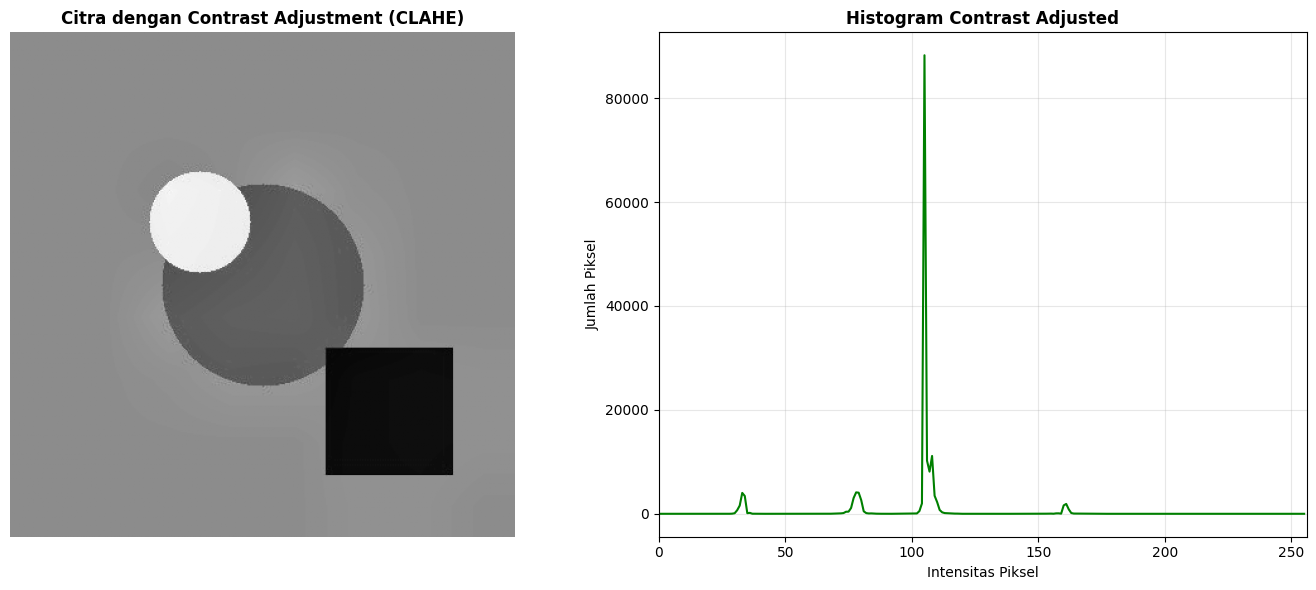


✓ Contrast telah diatur menggunakan CLAHE
  CLAHE meningkatkan kontras secara adaptif dengan membatasi amplifikasi noise


In [30]:
# Pengaturan Kontras Menggunakan CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
img_contrast = clahe.apply(img_grayscale)
print("="*70)
print(f"\nDimensi: {img_contrast.shape}")
print(f"Tipe data: {img_contrast.dtype}")
print(f"Min pixel value: {img_contrast.min()}")
print(f"Max pixel value: {img_contrast.max()}")
print(f"CLAHE clipLimit: 2.0")
print(f"CLAHE tileGridSize: (8, 8)")

# Tampilkan Citra dengan Contrast Adjustment dan Histogram
fig4 = plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_contrast, cmap='gray')
plt.title("Citra dengan Contrast Adjustment (CLAHE)", fontsize=12, fontweight='bold')
plt.axis('off')

plt.subplot(1, 2, 2)
hist = cv2.calcHist([img_contrast], [0], None, [256], [0, 256])
plt.plot(hist, color='green', linewidth=1.5)
plt.title("Histogram Contrast Adjusted", fontsize=12, fontweight='bold')
plt.xlabel("Intensitas Piksel")
plt.ylabel("Jumlah Piksel")
plt.xlim([0, 256])
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Contrast telah diatur menggunakan CLAHE")
print("  CLAHE meningkatkan kontras secara adaptif dengan membatasi amplifikasi noise")


Dimensi: (400, 400)
Tipe data: uint8
Min pixel value: 0
Max pixel value: 255


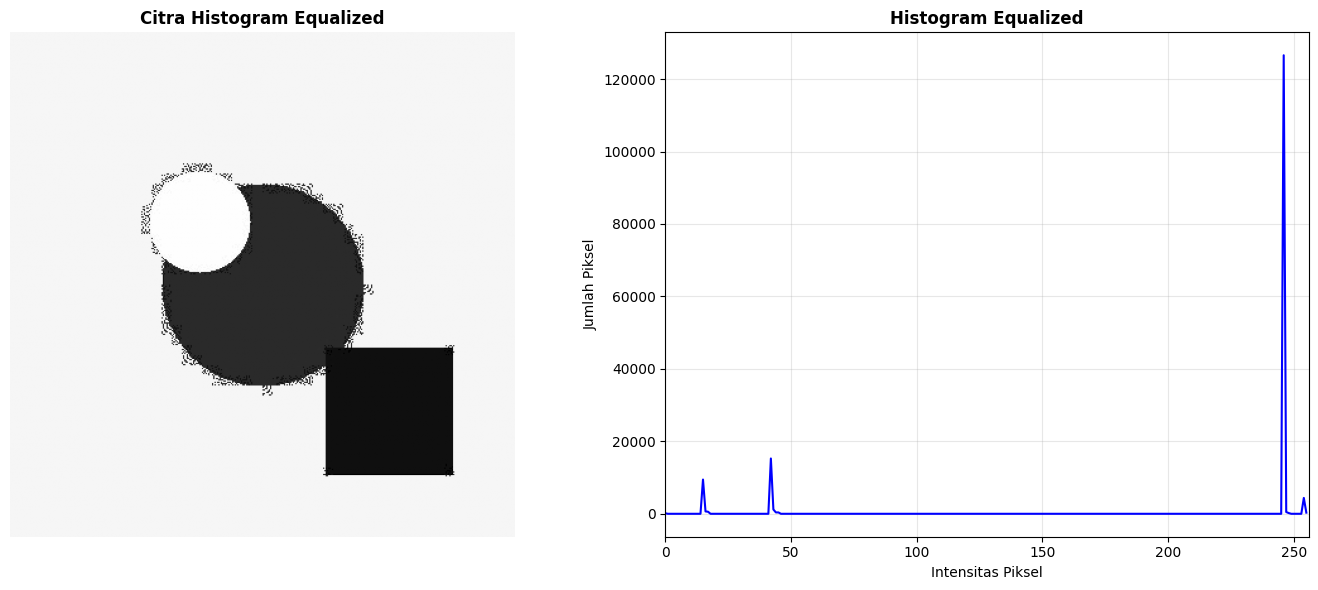


✓ Histogram equalization telah dilakukan
  Histogram equalization mendistribusikan intensitas piksel secara merata


In [31]:
# Histogram Equalization
img_equalized = cv2.equalizeHist(img_grayscale)
print(f"\nDimensi: {img_equalized.shape}")
print(f"Tipe data: {img_equalized.dtype}")
print(f"Min pixel value: {img_equalized.min()}")
print(f"Max pixel value: {img_equalized.max()}")

# Tampilkan Citra Histogram Equalized dan Histogram
fig5 = plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(img_equalized, cmap='gray')
plt.title("Citra Histogram Equalized", fontsize=12, fontweight='bold')
plt.axis('off')

plt.subplot(1, 2, 2)
hist = cv2.calcHist([img_equalized], [0], None, [256], [0, 256])
plt.plot(hist, color='blue', linewidth=1.5)
plt.title("Histogram Equalized", fontsize=12, fontweight='bold')
plt.xlabel("Intensitas Piksel")
plt.ylabel("Jumlah Piksel")
plt.xlim([0, 256])
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Histogram equalization telah dilakukan")
print("  Histogram equalization mendistribusikan intensitas piksel secara merata")

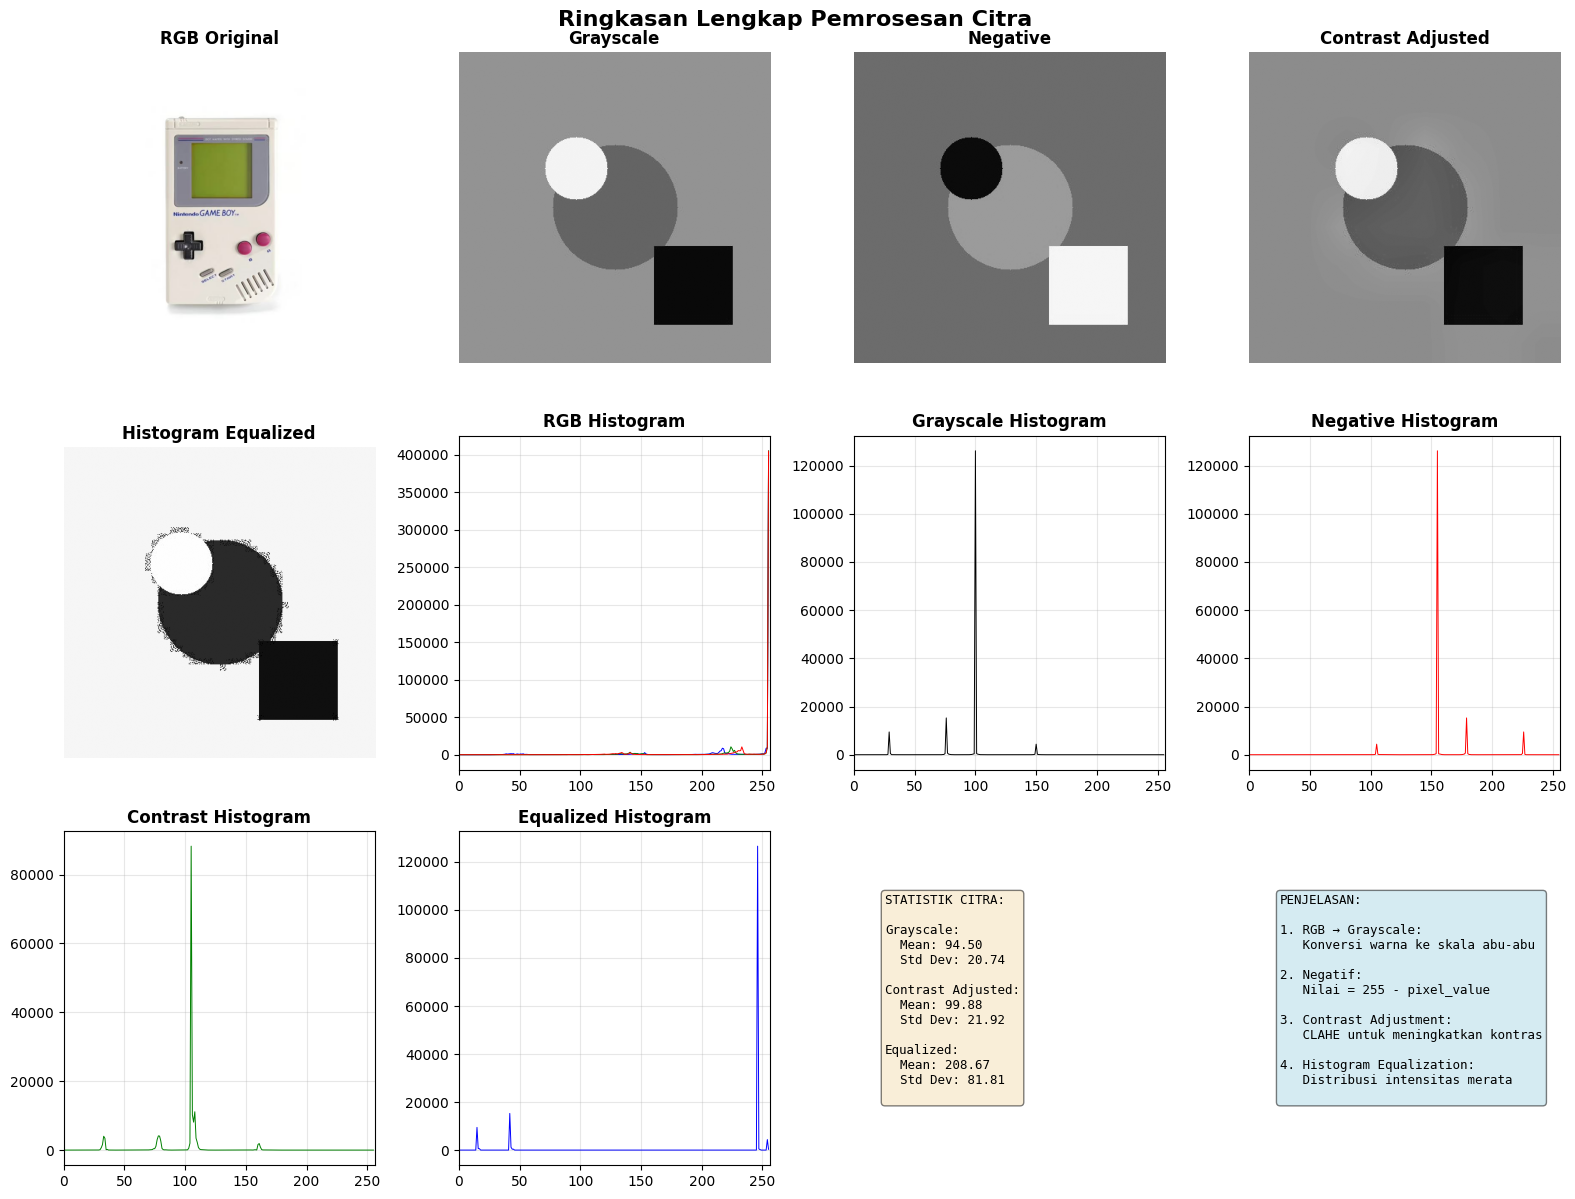

✓ Perbandingan lengkap telah ditampilkan
Pemrosesan citra selesai!


In [32]:
# Ringkasan Perbandingan Semua Tahap

fig_summary = plt.figure(figsize=(16, 12))

# Baris 1: Gambar semua tahap
plt.subplot(3, 4, 1)
plt.imshow(cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB))
plt.title("RGB Original", fontweight='bold')
plt.axis('off')

plt.subplot(3, 4, 2)
plt.imshow(img_grayscale, cmap='gray')
plt.title("Grayscale", fontweight='bold')
plt.axis('off')

plt.subplot(3, 4, 3)
plt.imshow(img_negative, cmap='gray')
plt.title("Negative", fontweight='bold')
plt.axis('off')

plt.subplot(3, 4, 4)
plt.imshow(img_contrast, cmap='gray')
plt.title("Contrast Adjusted", fontweight='bold')
plt.axis('off')

plt.subplot(3, 4, 5)
plt.imshow(img_equalized, cmap='gray')
plt.title("Histogram Equalized", fontweight='bold')
plt.axis('off')

# Baris 2: Histogram RGB
plt.subplot(3, 4, 6)
colors = ('b', 'g', 'r')
for i, color in enumerate(colors):
    hist = cv2.calcHist([img_rgb], [i], None, [256], [0, 256])
    plt.plot(hist, color=color, linewidth=0.7)
plt.title("RGB Histogram", fontweight='bold')
plt.xlim([0, 256])
plt.grid(True, alpha=0.3)

# Histogram Grayscale
plt.subplot(3, 4, 7)
hist = cv2.calcHist([img_grayscale], [0], None, [256], [0, 256])
plt.plot(hist, color='black', linewidth=0.7)
plt.title("Grayscale Histogram", fontweight='bold')
plt.xlim([0, 256])
plt.grid(True, alpha=0.3)

# Histogram Negative
plt.subplot(3, 4, 8)
hist = cv2.calcHist([img_negative], [0], None, [256], [0, 256])
plt.plot(hist, color='red', linewidth=0.7)
plt.title("Negative Histogram", fontweight='bold')
plt.xlim([0, 256])
plt.grid(True, alpha=0.3)

# Histogram Contrast
plt.subplot(3, 4, 9)
hist = cv2.calcHist([img_contrast], [0], None, [256], [0, 256])
plt.plot(hist, color='green', linewidth=0.7)
plt.title("Contrast Histogram", fontweight='bold')
plt.xlim([0, 256])
plt.grid(True, alpha=0.3)

# Histogram Equalized
plt.subplot(3, 4, 10)
hist = cv2.calcHist([img_equalized], [0], None, [256], [0, 256])
plt.plot(hist, color='blue', linewidth=0.7)
plt.title("Equalized Histogram", fontweight='bold')
plt.xlim([0, 256])
plt.grid(True, alpha=0.3)

# Statistics
plt.subplot(3, 4, 11)
plt.axis('off')
stats_text = f"""STATISTIK CITRA:

Grayscale:
  Mean: {np.mean(img_grayscale):.2f}
  Std Dev: {np.std(img_grayscale):.2f}

Contrast Adjusted:
  Mean: {np.mean(img_contrast):.2f}
  Std Dev: {np.std(img_contrast):.2f}

Equalized:
  Mean: {np.mean(img_equalized):.2f}
  Std Dev: {np.std(img_equalized):.2f}
"""
plt.text(0.1, 0.5, stats_text, fontsize=9, family='monospace',
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Penjelasan
plt.subplot(3, 4, 12)
plt.axis('off')
info_text = """PENJELASAN:

1. RGB → Grayscale: 
   Konversi warna ke skala abu-abu

2. Negatif:
   Nilai = 255 - pixel_value

3. Contrast Adjustment:
   CLAHE untuk meningkatkan kontras

4. Histogram Equalization:
   Distribusi intensitas merata
"""
plt.text(0.1, 0.5, info_text, fontsize=9, family='monospace',
         verticalalignment='center', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.tight_layout()
plt.suptitle("Ringkasan Lengkap Pemrosesan Citra", fontsize=16, fontweight='bold', y=0.995)
plt.show()

print("✓ Perbandingan lengkap telah ditampilkan")
print("Pemrosesan citra selesai!")